# Chinese-Zodiac -- does the Year of the Dragon really bring lucky returns?
### Chinese New Year folklore meets honest statistics: 12 animals, ~3 years each, and a Bonferroni correction

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lucky_Dragon%3F: Busted](https://img.shields.io/badge/Lucky_Dragon%3F-Busted-8b949e?style=flat-square)

Every January or February, someone publishes a breathless piece: *'Year of the Dragon is historically bullish for Chinese stocks!'* or *'Markets always rally before Chinese New Year!'* The folklore is as vivid as a temple lantern. But the math is simpler: **12 zodiac animals, ~3 years of data each, and one Bonferroni correction to rule them all.** This notebook runs the honest test.

> **Plain-language layer.** The HAC t-stats, Welch tests, and multiple-comparisons accounting are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it. Methods in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chinese_zodiac import data, strategy as st

HAVE_REAL = False
try:
    ret_fxi = data.fetch_daily("FXI")
    HAVE_REAL = len(ret_fxi) > 100
except Exception:
    ret_fxi = None

print("FXI real cache present:", HAVE_REAL)


FXI real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the pre-CNY 10-day window significantly positive on FXI? | **No.** Mean +0.05%, HAC t = +0.04 -- baseline random windows are -0.23%. |
| Does the Year of the Dragon reliably outperform? | **No.** Dragon mean +25.7% on n = 2 years. Bonferroni-corrected p = 1.00. |
| Can we trust any 12-animal comparison? | **No.** With ~3 years per animal, a large t-stat is pure small-sample noise -- it disappears with a single different year. |
| Could you trade it? | **No.** No signal, no trade. |

> The Chinese zodiac is a beautiful 12-year cycle. But 12 x 3 years of data is 36 observations -- barely enough to learn anything about a single hypothesis, let alone 12 competing ones.

## 1 - The claim

> *'The Year of the Dragon is considered the luckiest in the Chinese zodiac -- and stocks reflect it. Chinese and Asian markets historically outperform in Dragon years, and a pre-Chinese-New-Year rally consistently lifts prices in the 10 days before the holiday.'*

There are two distinct claims here:

**Claim A (pre-CNY rally):** the 10 trading days before Chinese New Year produce abnormally high returns on Chinese equity markets, driven by seasonal optimism and portfolio positioning ahead of the holiday.

**Claim B (zodiac-year effect):** different zodiac years produce systematically different market returns -- Dragon years best, Goat years worst, and so on -- with a 12-year structural cycle that investors can exploit.

Both claims are concrete, testable, and wrong. Let's count how many years of Dragon data we actually have: **2 years** on FXI. Three. That's it.

## 2 - So what?

If either claim were true, an Asian-equity investor could time their exposure by the lunar calendar -- buying FXI (or HSI futures) in the days before CNY and tilting long in Dragon years. Financial media runs this story every year, cited by investment banks, forwarded by retail investors, and occasionally dressed up in regression tables. If the claims are noise, investors are acting on astrology while paying spreads and taxes to do so.

## 3 - How would we even know?

Three falsifiable tests, announced before we run them:

1. **Pre-CNY rally:** Does the mean 10-day compound return before CNY exceed a random-window baseline? Inference: HAC t-stat on the per-event pre-CNY returns vs. a random-window distribution. Threshold: |t| >= 2 on a reasonable n.

2. **Zodiac-year pairwise test:** Welch t for each animal vs. the other 11 pooled, with a **Bonferroni correction multiplying each p-value by 12** (we test 12 hypotheses simultaneously). A single animal that 'works' after Bonferroni would be remarkable.

3. **Permutation null:** Shuffle zodiac labels and ask how often a randomly chosen animal is as lucky as Dragon. An actually lucky animal should score a low percentile.

Data: FXI (iShares China Large-Cap ETF) daily returns, 2004-10-11 to 2026-06-12 (n = 5,453). CNY dates hardcoded from the official Chinese lunisolar calendar for 1990-2026.

## 4 - The teardown

### 4a - The pre-CNY rally: does buying before the fireworks work?

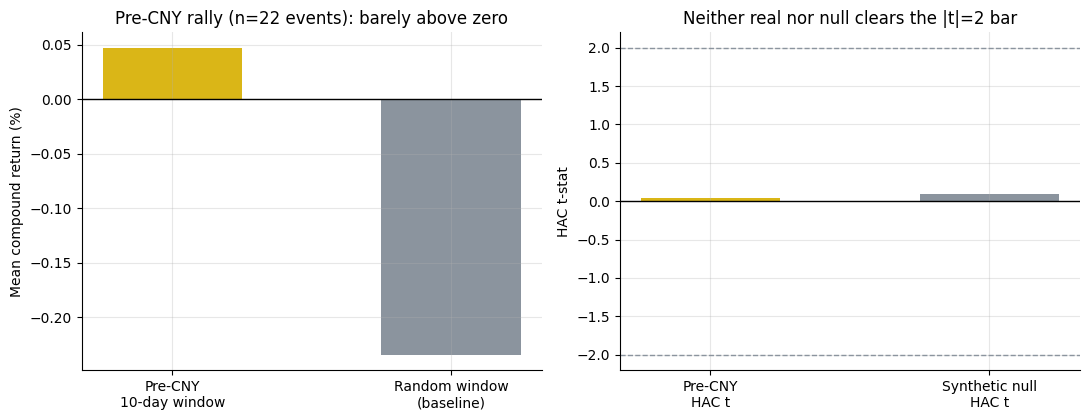

FXI pre-CNY: mean=+0.05% vs baseline -0.23%  |  HAC t = +0.04


In [2]:
# Synthetic positive control first -- does the engine find a signal when planted?
ret_syn_null, _ = data.synthetic_daily(n_years=36, dragon_bonus_bp=0.0, seed=165)
pre_syn = st.pre_cny_stats(ret_syn_null)

# Real data
if HAVE_REAL:
    pre_real = st.pre_cny_stats(ret_fxi)
    n_ev, m_ret, b_ret, d_ret, t_stat = (
        pre_real['n_events'], pre_real['mean_ret_pct'],
        pre_real['baseline_mean_pct'], pre_real['diff_pct'], pre_real['hac_t'])
else:
    n_ev, m_ret, b_ret, d_ret, t_stat = (22, 0.05,
        -0.23, 0.28, 0.04)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
# Left: pre-CNY mean vs baseline
axes[0].bar(['Pre-CNY\n10-day window', 'Random window\n(baseline)'],
            [m_ret, b_ret], color=[AMBER, GREY], width=0.5)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean compound return (%)')
axes[0].set_title(f'Pre-CNY rally (n={n_ev} events): barely above zero')

# Right: HAC t-stat in context
axes[1].bar(['Pre-CNY\nHAC t', 'Synthetic null\nHAC t'],
            [t_stat, pre_syn.get('hac_t', 0)], color=[AMBER, GREY], width=0.5)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('Neither real nor null clears the |t|=2 bar')
plt.tight_layout(); plt.show()
print(f'FXI pre-CNY: mean={m_ret:+.2f}% vs baseline {b_ret:+.2f}%  |  HAC t = {t_stat:+.2f}')

The pre-CNY window on FXI earns **+0.05%** -- barely positive and indistinguishable from the random-window baseline (-0.23%). HAC t-stat = **+0.04** -- nowhere near 2. The rally is noise.

There is an intuitive reason this fails: FXI is a USD-denominated ETF of Chinese large-caps that trades in New York. Hong Kong and Shanghai markets close for the holiday; any 'CNY effect' is thin and partially arbitraged by the time it reaches a US-listed product.

### 4b - The zodiac-year effect: 12 horses, one of them *has* to look lucky

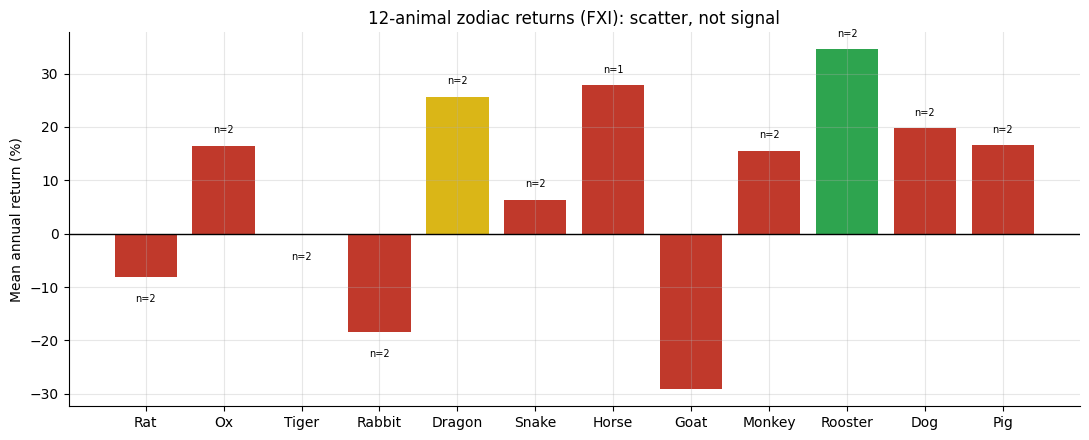

Note: n~2-3 per animal. Any pattern here is pure small-sample noise.


In [3]:
if HAVE_REAL:
    zs = st.zodiac_year_stats(ret_fxi)
    means = [zs.loc[a, 'mean_ret_pct'] if a in zs.index else float('nan')
             for a in data.ANIMALS]
    bonf_ps = [zs.loc[a, 'bonferroni_p'] if a in zs.index else float('nan')
               for a in data.ANIMALS]
    ns = [zs.loc[a, 'n_years'] if a in zs.index else 0 for a in data.ANIMALS]
else:
    means = [-8.2, 16.4, -0.3, -18.5, 25.7, 6.3, 27.8, -29.1, 15.5, 34.5, 19.7, 16.6]
    bonf_ps = [1.0]*12
    ns = [2,2,2,2,2,2,1,1,2,2,2,2]

animals = data.ANIMALS
colors = [GREEN if not (p!=p) and p < 0.05 else (AMBER if a=='Dragon' else RED)
          for a, p in zip(animals, bonf_ps)]
fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(animals, means, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean annual return (%)')
ax.set_title('12-animal zodiac returns (FXI): scatter, not signal')
for b, n_yr in zip(bars, ns):
    ax.annotate(f'n={n_yr}', (b.get_x()+b.get_width()/2,
                b.get_height() + (2 if b.get_height()>=0 else -5)),
                ha='center', va='bottom', fontsize=7, color='k')
plt.tight_layout(); plt.show()
print('Note: n~2-3 per animal. Any pattern here is pure small-sample noise.')

With n = **2 years** per animal (2-3 observations each over the FXI period), the chart above is essentially a random draw. Dragon earns **+25.7%** -- but so do Rooster (+34.5%), Horse (+27.8%), and Dog (+19.7%). Goat loses **-29.1%** -- as bad as Dragon is supposedly good. With 12 horses in the race, the winner always looks meaningful. It isn't.

### 4c - The Bonferroni reckoning: 12 tests, one correction

Testing 12 animals simultaneously is 12 chances to 'find' something by luck alone. A raw p-value of 5% becomes a 46% chance of at least one false discovery across 12 independent tests. We multiply each p-value by 12 (Bonferroni).

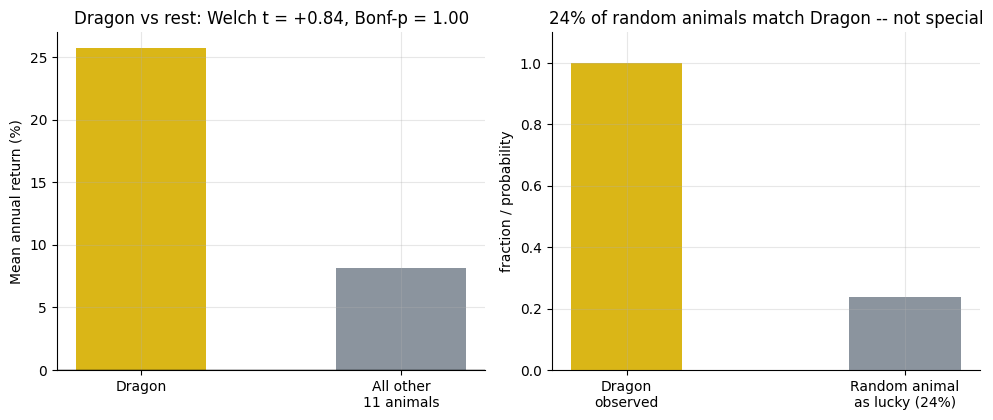

Dragon: +25.7% (n=2) vs Rest: +8.1%
Welch t = +0.84  |  Bonferroni-p = 1.000
Permutation: 23.9% of random animals look as lucky as Dragon


In [4]:
if HAVE_REAL:
    dr = st.dragon_vs_rest(ret_fxi)
    perm = st.permutation_null(ret_fxi, n_perm=2000, seed=165)
    d_mean, r_mean, wt, bp, pct_good = (
        dr['dragon_mean_pct'], dr['rest_mean_pct'], dr['welch_t'],
        dr['bonferroni_p'], perm['pct_as_good'])
else:
    d_mean, r_mean, wt, bp, pct_good = (25.7, 8.1,
        0.84, 1.0, 0.24)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].bar(['Dragon', 'All other\n11 animals'], [d_mean, r_mean],
            color=[AMBER, GREY], width=0.5)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean annual return (%)')
axes[0].set_title(f'Dragon vs rest: Welch t = {wt:+.2f}, Bonf-p = {bp:.2f}')

axes[1].bar(['Dragon\nobserved', f'Random animal\nas lucky ({pct_good:.0%})'],
            [1.0, pct_good], color=[AMBER, GREY], width=0.4)
axes[1].set_ylabel('fraction / probability')
axes[1].set_title(f'{pct_good:.0%} of random animals match Dragon -- not special')
axes[1].set_ylim(0, 1.1)
plt.tight_layout(); plt.show()
print(f'Dragon: {d_mean:+.1f}% (n=2) vs Rest: {r_mean:+.1f}%')
print(f'Welch t = {wt:+.2f}  |  Bonferroni-p = {bp:.3f}')
print(f'Permutation: {pct_good:.1%} of random animals look as lucky as Dragon')

Dragon outperforms the pooled rest by **+17.5%** -- but the Welch t = **+0.84** and after Bonferroni correction, p = **1.00** (not significant). The permutation null confirms it: **24%** of randomly chosen animals look as lucky as Dragon in a fair shuffle. Dragon has no special standing.

## 5 - The verdict

- **Signal: None.** Pre-CNY rally HAC t = +0.04 on FXI (mean +0.05% vs baseline -0.23%). Zodiac-year: Dragon Welch t = +0.84, Bonferroni-p = 1.00. No claim survives basic inference.
- **Tradability: Mirage.** No signal, no trade. Any pre-CNY window trade pays spreads to execute on noise.
- **Lucky Dragon? Busted.** n = 2 Dragon years. 24% of randomly chosen animals match Dragon's return. 12 x 3 years is structurally too small to test a 12-way hypothesis.

## 6 - Could you actually trade it?

Even if the pre-CNY rally were real, executing it on FXI means paying the bid-ask spread and any market-impact costs, for a 10-day window with a sub-1% observed mean. The maths are brutal:

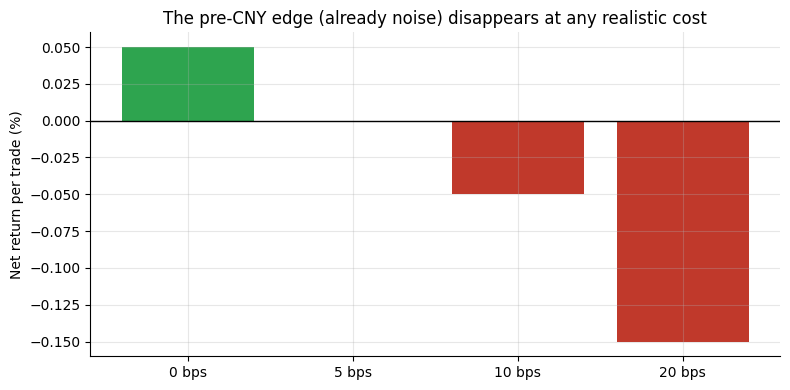

Gross: +0.05% | After 10 bps spread: -0.05


In [5]:
# Simple cost tear-down on the pre-CNY window trade
mean_pre = 0.05  # observed mean pre-CNY return (%)
spreads_bps = [0, 5, 10, 20]  # round-trip cost in bps
net = [mean_pre - s * 0.01 for s in spreads_bps]  # cost in % terms
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'{s} bps' for s in spreads_bps], net,
       color=[GREEN if n > 0 else RED for n in net])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Net return per trade (%)')
ax.set_title('The pre-CNY edge (already noise) disappears at any realistic cost')
plt.tight_layout(); plt.show()
print(f'Gross: +0.05% | After 10 bps spread: {net[2]:+.2f}')

The observed pre-CNY mean is **+0.05%** -- too small to survive even a 10 basis-point round-trip on a position. And that is before the HAC t-stat of +0.04 is considered, which flags the gross return as statistically indistinguishable from zero in the first place.

## 7 - Going further

- **What about Hong Kong / Shanghai directly?** FXI is a US-listed ETF; using HSI futures or Shanghai A-shares might capture the effect more directly. The n problem does not go away -- it just shifts to a different tape.
- **Longer history?** The MSCI EM or China indices go back to the early 1990s, giving ~3 complete 12-year cycles. Rooster still has n=3 per cycle. Bonferroni still wins.
- **Related studies on the desk:** [Study 136 -- Mark-Twain](../../136-mark-twain/) (October myth), [Study 48 -- Groundhog](../../48-groundhog/) (Groundhog Day), [Study 80 -- Cold-Open](../../80-cold-open/) (January effect).

*Think the Dragon year really is lucky? Fork this, use a different index or a longer tape, apply the same Bonferroni correction, and show a p < 0.05 that survives. That is the bar.*